Google Drive Mount

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


File verify

In [ ]:
import os
folder = "/content/drive/MyDrive/Project2_SolarPV"
print(os.listdir(folder))

['Plant_1_Generation_Data.csv', 'Plant_2_Generation_Data.csv', 'Plant_1_Weather_Sensor_Data.csv', 'Plant_2_Weather_Sensor_Data.csv']


##4 CVS'S STRUCTURES
#.columns.tolist()) - extract the names of columns

In [ ]:
import pandas as pd

folder = "/content/drive/MyDrive/Project2_SolarPV/"
files = [
    "Plant_1_Generation_Data.csv",
    "Plant_1_Weather_Sensor_Data.csv",
    "Plant_2_Generation_Data.csv",
    "Plant_2_Weather_Sensor_Data.csv",
]

for f in files:
    print("=" * 70)
    print("FILE:", f)
    print("=" * 70)
    try:
        df = pd.read_csv(folder + f)
        print("Shape:", df.shape)
        print("Columns:", df.columns.tolist())
        print("\nFirst 3 rows:")
        print(df.head(3))
        print("\nData types:")
        print(df.dtypes)
    except Exception as e:
        print("ERROR:", e)
    print()

FILE: Plant_1_Generation_Data.csv
Shape: (68778, 7)
Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']

First 3 rows:
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  

Data types:
DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object

FILE: Plant_1_Weather_Sensor_Data.csv
Shape: (3182, 6)
Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

First 3 rows:
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TE

##Plant 1 vs Plant 2
Data-driven decision which pant will be good.
Not guessing based on "Plant 1 is common"
#New learning
-df["column"].nunique() — unique values count

-df["column"].describe() — statistical summary (mean, std, quartiles, min, max)

-(df["column"] < 0).sum() — boolean mask + sum = counting

-set + & operator — set intersection (common items)

-df.isna().sum() — per-column missing value count


In [ ]:
import pandas as pd
import numpy as np

folder = "/content/drive/MyDrive/Project2_SolarPV/"

# Load all four
p1_gen = pd.read_csv(folder + "Plant_1_Generation_Data.csv")
p1_wth = pd.read_csv(folder + "Plant_1_Weather_Sensor_Data.csv")
p2_gen = pd.read_csv(folder + "Plant_2_Generation_Data.csv")
p2_wth = pd.read_csv(folder + "Plant_2_Weather_Sensor_Data.csv")

# Convert DATE_TIME consistently
for df in [p1_gen, p1_wth, p2_gen, p2_wth]:
    df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], dayfirst=False)

# PLANT 1 SUMMARY
print("=" * 70)
print("PLANT 1 SUMMARY")
print("=" * 70)

print("\nGeneration")
print("Rows:", len(p1_gen))
print("Unique inverters (SOURCE_KEY):", p1_gen["SOURCE_KEY"].nunique())
print("Date range:", p1_gen["DATE_TIME"].min(), "→", p1_gen["DATE_TIME"].max())
print("Missing values per column:\n", p1_gen.isna().sum())
print("AC_POWER stats:\n", p1_gen["AC_POWER"].describe())
print("Negative AC_POWER rows:", (p1_gen["AC_POWER"] < 0).sum())

print("\nWeather")
print("Rows:", len(p1_wth))
print("Unique sensors (SOURCE_KEY):", p1_wth["SOURCE_KEY"].nunique())
print("Date range:", p1_wth["DATE_TIME"].min(), "→", p1_wth["DATE_TIME"].max())
print("Missing values per column:\n", p1_wth.isna().sum())
print("IRRADIATION stats:\n", p1_wth["IRRADIATION"].describe())

# Check timestamp alignment between generation and weather
gen_ts = set(p1_gen["DATE_TIME"].unique())
wth_ts = set(p1_wth["DATE_TIME"].unique())
print("\nGen unique timestamps:", len(gen_ts))
print("Weather unique timestamps:", len(wth_ts))
print("Common timestamps:", len(gen_ts & wth_ts))
print("Only in gen:", len(gen_ts - wth_ts))
print("Only in weather:", len(wth_ts - gen_ts))

# PLANT 2 SUMMARY
print("\n" + "=" * 70)
print("PLANT 2 SUMMARY")
print("=" * 70)

print("\nGeneration")
print("Rows:", len(p2_gen))
print("Unique inverters (SOURCE_KEY):", p2_gen["SOURCE_KEY"].nunique())
print("Date range:", p2_gen["DATE_TIME"].min(), "→", p2_gen["DATE_TIME"].max())
print("Missing values per column:\n", p2_gen.isna().sum())
print("AC_POWER stats:\n", p2_gen["AC_POWER"].describe())
print("Negative AC_POWER rows:", (p2_gen["AC_POWER"] < 0).sum())

print("\nWeather")
print("Rows:", len(p2_wth))
print("Unique sensors (SOURCE_KEY):", p2_wth["SOURCE_KEY"].nunique())
print("Date range:", p2_wth["DATE_TIME"].min(), "→", p2_wth["DATE_TIME"].max())
print("Missing values per column:\n", p2_wth.isna().sum())
print("IRRADIATION stats:\n", p2_wth["IRRADIATION"].describe())

gen_ts = set(p2_gen["DATE_TIME"].unique())
wth_ts = set(p2_wth["DATE_TIME"].unique())
print("\nGen unique timestamps:", len(gen_ts))
print("Weather unique timestamps:", len(wth_ts))
print("Common timestamps:", len(gen_ts & wth_ts))
print("Only in gen:", len(gen_ts - wth_ts))
print("Only in weather:", len(wth_ts - gen_ts))

PLANT 1 SUMMARY

Generation
Rows: 68778
Unique inverters (SOURCE_KEY): 22
Date range: 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Missing values per column:
 DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
AC_POWER stats:
 count    68778.000000
mean       307.802752
std        394.396439
min          0.000000
25%          0.000000
50%         41.493750
75%        623.618750
max       1410.950000
Name: AC_POWER, dtype: float64
Negative AC_POWER rows: 0

Weather
Rows: 3182
Unique sensors (SOURCE_KEY): 1
Date range: 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Missing values per column:
 DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64
IRRADIATION stats:
 count    3182.000000
mean        0.228313
std         0.300836
min         0.000000
25%         0.000000
50%         0.024653
75%         0.449588

/tmp/ipykernel_491/3845901714.py:14: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], dayfirst=False)


##What I have got
Plant 1: gen timestamps 3158, weather 3182, common 3157

Plant 2: gen timestamps 3259, weather 3259, common 3259 (perfect)

in both plants, 22 inverter, 0 missing value, 0 negative power

##1. Date Format Verification
##2. Correct Date Parsing
**What I am doing:** Converting the `DATE_TIME` column of each file from a string to an actual datetime object.

Why there are different formats for each file:

As observed in the previous verification step:

Plant 1 Generation: DD-MM-YYYY HH:MM (length 16)

Plant 2 Generation: YYYY-MM-DD HH:MM:SS (length 19)

Weather (both): YYYY-MM-DD HH:MM:SS (length 19)

**Why specify the format:**

05-06-2020 — Is it June 5th or May 6th? Ambiguous!

Pandas' automatic parsing can make mistakes.

Explicit format = 100% deterministic.

##3.Hour Extraction
**What I am doing:** Extracting just the hour (0–23) from each row to create a new column named 'HOUR'.

Why:

Need to isolate daytime hours (6 AM – 6 PM)

Solar power output is always 0 at night—it adds no value to the analysis

Need to compare inverter performance only during daytime hours

**New concepts learned:**

.dt accessor — extracting components from a datetime column

.dt.hour — extracting just the hour

.dt.day, .dt.month, .dt.year, .dt.dayofweek — additional options

**Why I used** `for df in [p1_gen, p2_gen]`:

To avoid code duplication

To condense a two-line operation into a single line

Why I didn't do this for `p1_wth` and `p2_wth`:

We don't need the hour component from the weather data for this step

We are focusing solely on inverter behavior regarding power generation

##4.PLANT 2: Per-inverter daytime behavior
**What I am doing:**

Filtering daytime rows (6 AM – 6 PM)

Calculating 5 statistics for each inverter (SOURCE_KEY)

Displaying the results

In [ ]:
import pandas as pd
import numpy as np

folder = "/content/drive/MyDrive/Project2_SolarPV/"

# Load with explicit date formats
p1_gen = pd.read_csv(folder + "Plant_1_Generation_Data.csv")
p1_wth = pd.read_csv(folder + "Plant_1_Weather_Sensor_Data.csv")
p2_gen = pd.read_csv(folder + "Plant_2_Generation_Data.csv")
p2_wth = pd.read_csv(folder + "Plant_2_Weather_Sensor_Data.csv")

# Date Parsing
p1_gen["DATE_TIME"] = pd.to_datetime(p1_gen["DATE_TIME"], format="%d-%m-%Y %H:%M")
p2_gen["DATE_TIME"] = pd.to_datetime(p2_gen["DATE_TIME"], format="%Y-%m-%d %H:%M:%S") # Corrected format for p2_gen
p1_wth["DATE_TIME"] = pd.to_datetime(p1_wth["DATE_TIME"], format="%Y-%m-%d %H:%M:%S")
p2_wth["DATE_TIME"] = pd.to_datetime(p2_wth["DATE_TIME"], format="%Y-%m-%d %H:%M:%S")

# Add hour of day
for df in [p1_gen, p2_gen]:
    df["HOUR"] = df["DATE_TIME"].dt.hour

# PLANT 2: Per-inverter daytime behavior
print("=" * 70)
print("PLANT 2: PER-INVERTER AC_POWER (daytime only, 6 AM - 6 PM)")
print("=" * 70)

p2_day = p2_gen[(p2_gen["HOUR"] >= 6) & (p2_gen["HOUR"] <= 18)]

inverter_stats = p2_day.groupby("SOURCE_KEY")["AC_POWER"].agg(
    ["count", "mean", "median", "max", "std"]
).round(2)

print(inverter_stats)

print("\nInverters with zero daytime max power:")
zero_inverters = inverter_stats[inverter_stats["max"] == 0]
print(zero_inverters)
print("Count:", len(zero_inverters))

# PLANT 1: same
print("\n" + "=" * 70)
print("PLANT 1: PER-INVERTER AC_POWER (daytime only, 6 AM - 6 PM)")
print("=" * 70)

p1_day = p1_gen[(p1_gen["HOUR"] >= 6) & (p1_gen["HOUR"] <= 18)]

inverter_stats_1 = p1_day.groupby("SOURCE_KEY")["AC_POWER"].agg(
    ["count", "mean", "median", "max", "std"]
).round(2)

print(inverter_stats_1)

print("\nInverters with zero daytime max power:")
zero_inverters_1 = inverter_stats_1[inverter_stats_1["max"] == 0]
print(zero_inverters_1)
print("Count:", len(zero_inverters_1))

# Plant-level daily mean comparison
print("\n" + "=" * 70)
print("PLANT-LEVEL DAILY-MEAN AC_POWER COMPARISON (daytime only)")
print("=" * 70)

p1_day_plant = p1_day.groupby("DATE_TIME")["AC_POWER"].sum()
p2_day_plant = p2_day.groupby("DATE_TIME")["AC_POWER"].sum()

print("\nPlant 1 daytime plant-level AC_POWER (sum across 22 inverters):")
print(p1_day_plant.describe())

print("\nPlant 2 daytime plant-level AC_POWER (sum across 22 inverters):")
print(p2_day_plant.describe())

PLANT 2: PER-INVERTER AC_POWER (daytime only, 6 AM - 6 PM)
                 count    mean  median      max     std
SOURCE_KEY                                             
4UPUqMRk7TRMgml   1731  501.26  447.51  1384.35  410.99
81aHJ1q11NBPMrL   1764  417.03  336.76  1347.66  386.52
9kRcWv60rDACzjR   1764  442.07  379.00  1361.67  389.42
Et9kgGMDl729KT4   1731  340.04  241.61  1172.65  335.78
IQ2d7wF4YD8zU1Q   1275  515.68  466.36  1383.46  395.60
LYwnQax7tkwH5Cb   1764  354.89  261.52  1265.67  344.97
LlT2YUhhzqhg5Sw   1764  443.61  384.58  1338.35  387.78
Mx2yZCDsyf6DPfv   1731  514.34  464.66  1377.15  411.83
NgDl19wMapZy17u   1275  494.06  450.09  1370.96  386.10
PeE6FRyGXUgsRhN   1764  449.36  386.40  1347.53  387.87
Qf4GUc1pJu5T6c6   1731  503.04  451.23  1369.39  412.15
Quc1TzYxW2pYoWX   1731  313.12  241.95  1205.71  298.59
V94E5Ben1TlhnDV   1764  473.61  415.91  1333.07  404.97
WcxssY2VbP4hApt   1764  443.09  366.59  1363.51  398.87
mqwcsP2rE7J0TFp   1275  498.00  452.45  1372.

VARIFICATION CODE

In [ ]:
import pandas as pd

folder = "/content/drive/MyDrive/Project2_SolarPV/"

# শুধু raw strings হিসেবে পড়ো, datetime conversion ছাড়া
p1_gen_raw = pd.read_csv(folder + "Plant_1_Generation_Data.csv", dtype=str)
p2_gen_raw = pd.read_csv(folder + "Plant_2_Generation_Data.csv", dtype=str)
p1_wth_raw = pd.read_csv(folder + "Plant_1_Weather_Sensor_Data.csv", dtype=str)
p2_wth_raw = pd.read_csv(folder + "Plant_2_Weather_Sensor_Data.csv", dtype=str)

print("=" * 70)
print("DATE_TIME RAW FORMAT CHECK")
print("=" * 70)

print("\nPlant 1 Generation — first 5 DATE_TIME values:")
print(p1_gen_raw["DATE_TIME"].head(5).tolist())

print("\nPlant 2 Generation — first 5 DATE_TIME values:")
print(p2_gen_raw["DATE_TIME"].head(5).tolist())

print("\nPlant 1 Weather — first 5 DATE_TIME values:")
print(p1_wth_raw["DATE_TIME"].head(5).tolist())

print("\nPlant 2 Weather — first 5 DATE_TIME values:")
print(p2_wth_raw["DATE_TIME"].head(5).tolist())

# Random sampling — file-এর মাঝখান থেকে দেখি
print("\n" + "=" * 70)
print("RANDOM SAMPLING (middle of file)")
print("=" * 70)

print("\nPlant 1 Gen — 5 random DATE_TIME:")
print(p1_gen_raw["DATE_TIME"].sample(5, random_state=42).tolist())

print("\nPlant 2 Gen — 5 random DATE_TIME:")
print(p2_gen_raw["DATE_TIME"].sample(5, random_state=42).tolist())

# Length check — format-এর length দিয়ে বুঝতে পারব
print("\n" + "=" * 70)
print("STRING LENGTH CHECK (format-এর pattern বের করার জন্য)")
print("=" * 70)

print("\nPlant 1 Gen DATE_TIME string lengths:")
print(p1_gen_raw["DATE_TIME"].str.len().value_counts())

print("\nPlant 2 Gen DATE_TIME string lengths:")
print(p2_gen_raw["DATE_TIME"].str.len().value_counts())

print("\nPlant 1 Weather DATE_TIME string lengths:")
print(p1_wth_raw["DATE_TIME"].str.len().value_counts())

print("\nPlant 2 Weather DATE_TIME string lengths:")
print(p2_wth_raw["DATE_TIME"].str.len().value_counts())

DATE_TIME RAW FORMAT CHECK

Plant 1 Generation — first 5 DATE_TIME values:
['15-05-2020 00:00', '15-05-2020 00:00', '15-05-2020 00:00', '15-05-2020 00:00', '15-05-2020 00:00']

Plant 2 Generation — first 5 DATE_TIME values:
['2020-05-15 00:00:00', '2020-05-15 00:00:00', '2020-05-15 00:00:00', '2020-05-15 00:00:00', '2020-05-15 00:00:00']

Plant 1 Weather — first 5 DATE_TIME values:
['2020-05-15 00:00:00', '2020-05-15 00:15:00', '2020-05-15 00:30:00', '2020-05-15 00:45:00', '2020-05-15 01:00:00']

Plant 2 Weather — first 5 DATE_TIME values:
['2020-05-15 00:00:00', '2020-05-15 00:15:00', '2020-05-15 00:30:00', '2020-05-15 00:45:00', '2020-05-15 01:00:00']

RANDOM SAMPLING (middle of file)

Plant 1 Gen — 5 random DATE_TIME:
['10-06-2020 19:00', '28-05-2020 00:15', '17-05-2020 15:15', '01-06-2020 04:15', '17-05-2020 09:00']

Plant 2 Gen — 5 random DATE_TIME:
['2020-05-28 10:00:00', '2020-06-16 11:15:00', '2020-05-17 18:45:00', '2020-05-21 23:00:00', '2020-06-05 23:15:00']

STRING LENGTH CH

For Plant 2- (inverter-level daytime behavior inspect)

In [ ]:
import pandas as pd
import numpy as np

folder = "/content/drive/MyDrive/Project2_SolarPV/"

# Load with CORRECT date formats
p1_gen = pd.read_csv(folder + "Plant_1_Generation_Data.csv")
p1_wth = pd.read_csv(folder + "Plant_1_Weather_Sensor_Data.csv")
p2_gen = pd.read_csv(folder + "Plant_2_Generation_Data.csv")
p2_wth = pd.read_csv(folder + "Plant_2_Weather_Sensor_Data.csv")

# CORRECTED parsing — different formats for different files
p1_gen["DATE_TIME"] = pd.to_datetime(p1_gen["DATE_TIME"], format="%d-%m-%Y %H:%M")
p2_gen["DATE_TIME"] = pd.to_datetime(p2_gen["DATE_TIME"], format="%Y-%m-%d %H:%M:%S")
p1_wth["DATE_TIME"] = pd.to_datetime(p1_wth["DATE_TIME"], format="%Y-%m-%d %H:%M:%S")
p2_wth["DATE_TIME"] = pd.to_datetime(p2_wth["DATE_TIME"], format="%Y-%m-%d %H:%M:%S")

# Add hour of day
for df in [p1_gen, p2_gen]:
    df["HOUR"] = df["DATE_TIME"].dt.hour

# PLANT 2: Per-inverter daytime behavior
print("=" * 70)
print("PLANT 2: PER-INVERTER AC_POWER (daytime only, 6 AM - 6 PM)")
print("=" * 70)

p2_day = p2_gen[(p2_gen["HOUR"] >= 6) & (p2_gen["HOUR"] <= 18)]

inverter_stats_2 = p2_day.groupby("SOURCE_KEY")["AC_POWER"].agg(
    ["count", "mean", "median", "max", "std"]
).round(2)

print(inverter_stats_2)

print("\nInverters with zero daytime max power:")
zero_inverters_2 = inverter_stats_2[inverter_stats_2["max"] == 0]
print(zero_inverters_2)
print("Count of zero-max inverters:", len(zero_inverters_2))

# PLANT 1: same
print("\n" + "=" * 70)
print("PLANT 1: PER-INVERTER AC_POWER (daytime only, 6 AM - 6 PM)")
print("=" * 70)

p1_day = p1_gen[(p1_gen["HOUR"] >= 6) & (p1_gen["HOUR"] <= 18)]

inverter_stats_1 = p1_day.groupby("SOURCE_KEY")["AC_POWER"].agg(
    ["count", "mean", "median", "max", "std"]
).round(2)

print(inverter_stats_1)

print("\nInverters with zero daytime max power:")
zero_inverters_1 = inverter_stats_1[inverter_stats_1["max"] == 0]
print(zero_inverters_1)
print("Count of zero-max inverters:", len(zero_inverters_1))

# Plant-level daily mean comparison
print("\n" + "=" * 70)
print("PLANT-LEVEL DAYTIME AC_POWER COMPARISON")
print("=" * 70)

p1_day_plant = p1_day.groupby("DATE_TIME")["AC_POWER"].sum()
p2_day_plant = p2_day.groupby("DATE_TIME")["AC_POWER"].sum()

print("\nPlant 1 — plant-level AC_POWER (sum of 22 inverters):")
print(p1_day_plant.describe())

print("\nPlant 2 — plant-level AC_POWER (sum of 22 inverters):")
print(p2_day_plant.describe())

PLANT 2: PER-INVERTER AC_POWER (daytime only, 6 AM - 6 PM)
                 count    mean  median      max     std
SOURCE_KEY                                             
4UPUqMRk7TRMgml   1731  501.26  447.51  1384.35  410.99
81aHJ1q11NBPMrL   1764  417.03  336.76  1347.66  386.52
9kRcWv60rDACzjR   1764  442.07  379.00  1361.67  389.42
Et9kgGMDl729KT4   1731  340.04  241.61  1172.65  335.78
IQ2d7wF4YD8zU1Q   1275  515.68  466.36  1383.46  395.60
LYwnQax7tkwH5Cb   1764  354.89  261.52  1265.67  344.97
LlT2YUhhzqhg5Sw   1764  443.61  384.58  1338.35  387.78
Mx2yZCDsyf6DPfv   1731  514.34  464.66  1377.15  411.83
NgDl19wMapZy17u   1275  494.06  450.09  1370.96  386.10
PeE6FRyGXUgsRhN   1764  449.36  386.40  1347.53  387.87
Qf4GUc1pJu5T6c6   1731  503.04  451.23  1369.39  412.15
Quc1TzYxW2pYoWX   1731  313.12  241.95  1205.71  298.59
V94E5Ben1TlhnDV   1764  473.61  415.91  1333.07  404.97
WcxssY2VbP4hApt   1764  443.09  366.59  1363.51  398.87
mqwcsP2rE7J0TFp   1275  498.00  452.45  1372.

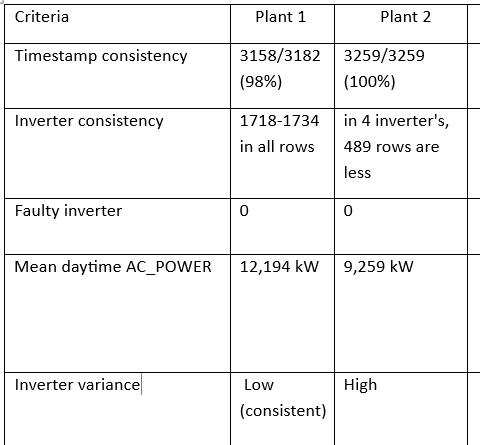

#Decision: Plant 1
However, there is a trade-off: Plant 2 has perfect timestamps, but higher inverter variance. Plant 1 has no generation data for 25 weather timestamps—merging results in a 0.78% data loss, which is negligible.

Decisions based on data, not assumptions.

##Plant 1- generation data plant-level aggregate, merge and merged dataset verify

**What I did:** Summed the power output of 22 inverters to calculate plant-level power.

**Why:** Weather data is at the plant level, and the target is also at the plant level. Therefore, the AC_POWER from all inverters needs to be summed.

**New learnings:**

df.groupby("DATE_TIME").agg({...}) — performing multiple aggregations using a dictionary

.reset_index() — converting the index back into a column after a groupby operation

In [ ]:
import pandas as pd
import numpy as np

folder = "/content/drive/MyDrive/Project2_SolarPV/"

# Load Plant 1 only
gen = pd.read_csv(folder + "Plant_1_Generation_Data.csv")
wth = pd.read_csv(folder + "Plant_1_Weather_Sensor_Data.csv")

# Correct parsing
gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"], format="%d-%m-%Y %H:%M")
wth["DATE_TIME"] = pd.to_datetime(wth["DATE_TIME"], format="%Y-%m-%d %H:%M:%S")

print("=" * 70)
print("BEFORE AGGREGATION")
print("=" * 70)
print("Generation rows:", len(gen))
print("Generation unique timestamps:", gen["DATE_TIME"].nunique())
print("Weather rows:", len(wth))
print("Weather unique timestamps:", wth["DATE_TIME"].nunique())

# Aggregate generation to plant level
gen_plant = gen.groupby("DATE_TIME").agg({
    "DC_POWER": "sum",
    "AC_POWER": "sum",
    "DAILY_YIELD": "sum",   # will be dropped later but keep for now
    "TOTAL_YIELD": "sum",   # will be dropped later but keep for now
}).reset_index()

print("\n" + "=" * 70)
print("AFTER AGGREGATION")
print("=" * 70)
print("Aggregated generation rows:", len(gen_plant))
print("Sample:")
print(gen_plant.head())

# Prepare weather (drop SOURCE_KEY and PLANT_ID)
wth_clean = wth[["DATE_TIME", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]].copy()

# Merge on DATE_TIME (inner join)
merged = pd.merge(gen_plant, wth_clean, on="DATE_TIME", how="inner")

print("\n" + "=" * 70)
print("MERGED DATASET")
print("=" * 70)
print("Merged shape:", merged.shape)
print("Merged columns:", merged.columns.tolist())
print("\nFirst 5 rows:")
print(merged.head())
print("\nLast 5 rows:")
print(merged.tail())
print("\nMissing values:")
print(merged.isna().sum())
print("\nDate range:", merged["DATE_TIME"].min(), "→", merged["DATE_TIME"].max())
print("\nAC_POWER stats (plant-level):")
print(merged["AC_POWER"].describe())

BEFORE AGGREGATION
Generation rows: 68778
Generation unique timestamps: 3158
Weather rows: 3182
Weather unique timestamps: 3182

AFTER AGGREGATION
Aggregated generation rows: 3158
Sample:
            DATE_TIME  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD
0 2020-05-15 00:00:00       0.0       0.0          0.0  143581676.0
1 2020-05-15 00:15:00       0.0       0.0          0.0  143581676.0
2 2020-05-15 00:30:00       0.0       0.0          0.0  143581676.0
3 2020-05-15 00:45:00       0.0       0.0          0.0  143581676.0
4 2020-05-15 01:00:00       0.0       0.0          0.0  150761642.0

MERGED DATASET
Merged shape: (3157, 8)
Merged columns: ['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

First 5 rows:
            DATE_TIME  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD  \
0 2020-05-15 00:00:00       0.0       0.0          0.0  143581676.0   
1 2020-05-15 00:15:00       0.0       0.0          0.0  1435816

##What I have Got
Aggregation - 68,778 rows → 3,158 rows (22 inverter → 1 plant row)

Merged shape: (3157, 8)

Missing values: 0 (all columns)

Expected loss: 3158 → 3157, just 1 row (0.03%)